<a href="https://colab.research.google.com/github/ShubhamP1028/Spiking-Neural-Networks/blob/main/MNIST_using_izihikevich.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1></h1>
<h1 align='center'> SNN on MNIST dataset using Izhikevich</h1>



In [1]:
!pip install -q snntorch==0.9.4 torch torchvision matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 4.8 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import snntorch as snn
from snntorch import surrogate
import numpy as np
import random
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

In [3]:
# Reproducible seeds
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
# Hyperparameters
# ---------------------------------------------------------
batch_size = 128
epochs = 12
lr = 1e-3
num_steps = 20          # SNN time steps (temporal dimension)
izh_threshold = 30.0    # spike threshold for Izhikevich neurons (standard)
input_size = (1, 28, 28)
num_classes = 10

In [5]:
# MNIST dataloaders (normalized)
# ---------------------------------------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 21.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 532kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.36MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.5MB/s]


In [6]:
# Izhikevich neuron layer (vectorized) with surrogate
# ---------------------------------------------------------
class IzhikevichLayer(nn.Module):
    """
    Vectorized Izhikevich neuron layer. Operates on input_current of shape (batch, neurons).
    Uses surrogate gradient for the spike generation.
    """
    def __init__(self, n_neurons, a=0.02, b=0.2, c=-65.0, d=8.0, dt=1.0, threshold=30.0, surrogate_fn=None, device="cpu"):
        """
        n_neurons: number of neurons in this layer
        a,b,c,d: izhikevich parameters (defaults produce regular spiking-like behavior)
        dt: time step scaling
        threshold: spike threshold (v >= threshold => spike)
        surrogate_fn: snntorch surrogate function (e.g., surrogate.fast_sigmoid())
        """
        super().__init__()
        self.n = n_neurons
        self.a = a
        self.b = b
        self.c = c
        self.d = d
        self.dt = dt
        self.threshold = threshold
        # Use fast sigmoid surrogate by default if none provided
        self.spike_fn = surrogate_fn if surrogate_fn is not None else surrogate.fast_sigmoid(slope=25.0)
        self.device = device

        # Note: we do NOT store v and u as persistent module buffers (we'll initialize per batch in forward)
        # so the module is stateless wrt batches (simpler for training loops)

    def forward(self, input_current, v_init=None, u_init=None):
        """
        input_current: (batch, n_neurons) current for this time step
        v_init, u_init: initial states (batch, n_neurons). If None, they will be initialized to defaults.
        Returns:
          spikes: surrogate spikes (batch, n_neurons) (values near 0/1)
          v, u: updated membrane and recovery variables
        """
        # input_current expected to be same shape as (batch, n_neurons)
        batch = input_current.shape[0]
        dtype = input_current.dtype
        dev = input_current.device

        # Initialize v and u if not provided
        if v_init is None:
            v = torch.full((batch, self.n), -65.0, dtype=dtype, device=dev)  # membrane potential
        else:
            v = v_init

        if u_init is None:
            u = torch.full((batch, self.n), self.b * -65.0, dtype=dtype, device=dev)  # recovery
        else:
            u = u_init

        # Izhikevich update (Euler integration)
        # v' = v + dt * (0.04 v^2 + 5 v + 140 - u + I)
        # u' = u + dt * a * (b*v - u)
        v_new = v + (0.04 * v * v + 5.0 * v + 140.0 - u + input_current) * self.dt
        u_new = u + (self.a * (self.b * v - u)) * self.dt

        # Surrogate spike: treat spike when v_new >= threshold
        # Use surrogate function on v_new - threshold to get gradient-friendly spike output
        spike_input = v_new - self.threshold
        spikes = self.spike_fn(spike_input)

        # Hard reset for variables where spike occurred (non-differentiable part for forward)
        spk_mask = (v_new >= self.threshold).float()
        if spk_mask.any():
            v_new = torch.where(spk_mask.bool(), torch.full_like(v_new, self.c), v_new)
            u_new = u_new + self.d * spk_mask

        return spikes, v_new, u_new

In [7]:
# Full model: analog conv front-end -> linear mapping -> spiking layers
# ---------------------------------------------------------
class ConvIzhSNN(nn.Module):
    def __init__(self, num_classes=10, hidden_spike_neurons=512, izh_params=None, device="cpu"):
        """
        num_classes: MNIST classes (10)
        hidden_spike_neurons: neurons in hidden spiking layer
        izh_params: dict of izhikevich params (a,b,c,d,dt)
        """
        super().__init__()
        self.device = device
        # Convolutional feature extractor (analog)
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # 1x28x28 -> 32x28x28
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                             # -> 32x14x14

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # -> 64x14x14
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                             # -> 64x7x7
        )

        # Flatten and map to spike-layer input dimensionality
        conv_flatten_dim = 64 * 7 * 7
        self.fc_feat = nn.Linear(conv_flatten_dim, hidden_spike_neurons, bias=True)  # produce currents for izh layer
        # Hidden spiking layer (Izhikevich)
        izh_params = izh_params or {}
        self.izh_hidden = IzhikevichLayer(
            n_neurons=hidden_spike_neurons,
            a=izh_params.get("a", 0.02),
            b=izh_params.get("b", 0.2),
            c=izh_params.get("c", -65.0),
            d=izh_params.get("d", 8.0),
            dt=izh_params.get("dt", 1.0),
            threshold=izh_params.get("threshold", izh_threshold),
            surrogate_fn=surrogate.fast_sigmoid(slope=25.0),
            device=device
        )

        # Map hidden spikes to output neurons (current for output izh layer)
        # Use linear layer that receives spikes and produces currents to output izh neurons
        self.fc_out = nn.Linear(hidden_spike_neurons, num_classes, bias=True)

        # Output spiking layer (Izhikevich)
        self.izh_out = IzhikevichLayer(
            n_neurons=num_classes,
            a=izh_params.get("a_out", 0.02),
            b=izh_params.get("b_out", 0.2),
            c=izh_params.get("c_out", -65.0),
            d=izh_params.get("d_out", 2.0),
            dt=izh_params.get("dt_out", 1.0),
            threshold=izh_params.get("threshold_out", izh_threshold),
            surrogate_fn=surrogate.fast_sigmoid(slope=25.0),
            device=device
        )

    def forward(self, x, num_steps=20):
        """
        x: input images (batch, 1, 28, 28)
        num_steps: number of timesteps to run SNN dynamics
        Returns:
          out_spikes_record: Tensor of shape (T, batch, num_classes)
        """
        batch = x.size(0)
        dev = x.device
        dtype = x.dtype

        # Analog feature extraction (single pass)
        feat = self.conv_layers(x)          # (batch, 64, 7, 7)
        feat = feat.view(batch, -1)         # (batch, conv_flatten_dim)
        # Map to current space for hidden izh layer (static feature current)
        feat_current = self.fc_feat(feat)   # (batch, hidden_spike_neurons)
        # We'll feed feat_current as the input current at every time step (constant current encoding)
        # Alternative encodings (poisson) can be used for richer temporal patterns.

        # Initialize states for both Izh layers
        v_h = torch.full((batch, self.izh_hidden.n), -65.0, dtype=dtype, device=dev)
        u_h = torch.full((batch, self.izh_hidden.n), self.izh_hidden.b * -65.0, dtype=dtype, device=dev)
        v_o = torch.full((batch, self.izh_out.n), -65.0, dtype=dtype, device=dev)
        u_o = torch.full((batch, self.izh_out.n), self.izh_out.b * -65.0, dtype=dtype, device=dev)

        # Record spikes over time for output
        spk_record = torch.zeros(num_steps, batch, self.izh_out.n, device=dev, dtype=dtype)

        # Run for num_steps time steps
        for t in range(num_steps):
            # Hidden spiking layer: take constant current = feat_current
            spk_h, v_h, u_h = self.izh_hidden(feat_current, v_init=v_h, u_init=u_h)
            # Map hidden spikes to output currents
            out_current = self.fc_out(spk_h)  # (batch, num_classes)
            # Output spiking layer
            spk_o, v_o, u_o = self.izh_out(out_current, v_init=v_o, u_init=u_o)
            spk_record[t] = spk_o

        # Return full spike train from output layer (T, batch, num_classes)
        return spk_record

In [8]:
# Utility: compute accuracy given spike output (T, batch, classes)
# ---------------------------------------------------------
def spikes_to_preds(spk_record):
    """
    Sum spikes across time and take argmax as predicted class.
    spk_record: (T, batch, classes)
    Returns: preds (batch,)
    """
    summed = spk_record.sum(dim=0)  # (batch, classes)
    preds = summed.argmax(dim=1)
    return preds


In [9]:
# Instantiate model, loss, optimizer
# ---------------------------------------------------------
model = ConvIzhSNN(num_classes=num_classes, hidden_spike_neurons=512, device=device).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

In [10]:
# Training and evaluation loops
# ---------------------------------------------------------
def train_epoch(model, loader, optimizer, criterion, device, num_steps=20):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    pbar = tqdm(loader, desc="Train", leave=False)
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        # Forward: returns (T, batch, classes)
        spk_out = model(images, num_steps=num_steps)
        # Convert to logits by summing spikes over time (rate-coded)
        logits = spk_out.sum(dim=0)  # (batch, classes)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix({"loss": f"{running_loss/total:.4f}", "acc": f"{100*correct/total:.2f}"})

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc


In [11]:
@torch.no_grad()
def evaluate(model, loader, device, num_steps=20):
    model.eval()
    total = 0
    correct = 0
    losses = 0.0
    for images, labels in tqdm(loader, desc="Eval", leave=False):
        images = images.to(device)
        labels = labels.to(device)
        spk_out = model(images, num_steps=num_steps)
        logits = spk_out.sum(dim=0)
        loss = criterion(logits, labels)
        losses += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return losses / total, 100.0 * correct / total

In [ ]:
# # Run training
# # ---------------------------------------------------------
# train_losses = []
# train_accs = []
# test_losses = []
# test_accs = []

# for epoch in range(1, epochs + 1):
#     print(f"\nEpoch {epoch}/{epochs}")
#     tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device, num_steps=num_steps)
#     te_loss, te_acc = evaluate(model, test_loader, device, num_steps=num_steps)

#     train_losses.append(tr_loss)
#     train_accs.append(tr_acc)
#     test_losses.append(te_loss)
#     test_accs.append(te_acc)

#     print(f"Train Loss: {tr_loss:.4f}, Train Acc: {tr_acc:.2f}% | Test Loss: {te_loss:.4f}, Test Acc: {te_acc:.2f}%")


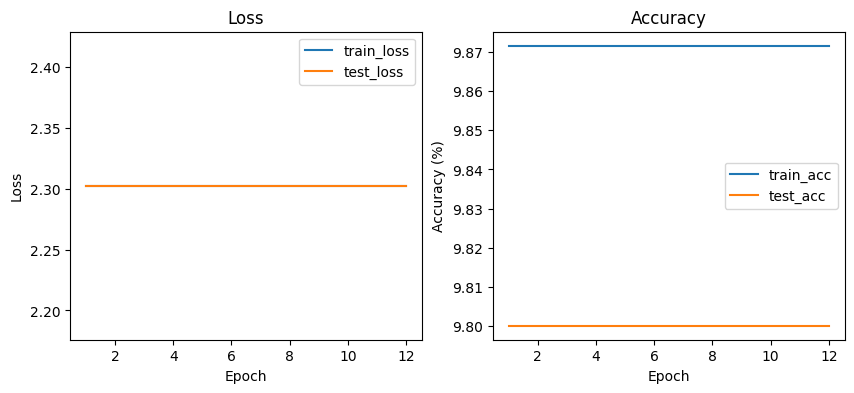

In [ ]:
# Plot training curves
# ---------------------------------------------------------
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(range(1, epochs+1), train_losses, label='train_loss')
plt.plot(range(1, epochs+1), test_losses, label='test_loss')
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(range(1, epochs+1), train_accs, label='train_acc')
plt.plot(range(1, epochs+1), test_accs, label='test_acc')
plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)"); plt.legend()
plt.title("Accuracy")
plt.show()


Final predictions:   0%|          | 0/79 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0     0.0980    1.0000    0.1785       980
           1     0.0000    0.0000    0.0000      1135
           2     0.0000    0.0000    0.0000      1032
           3     0.0000    0.0000    0.0000      1010
           4     0.0000    0.0000    0.0000       982
           5     0.0000    0.0000    0.0000       892
           6     0.0000    0.0000    0.0000       958
           7     0.0000    0.0000    0.0000      1028
           8     0.0000    0.0000    0.0000       974
           9     0.0000    0.0000    0.0000      1009

    accuracy                         0.0980     10000
   macro avg     0.0098    0.1000    0.0179     10000
weighted avg     0.0096    0.0980    0.0175     10000



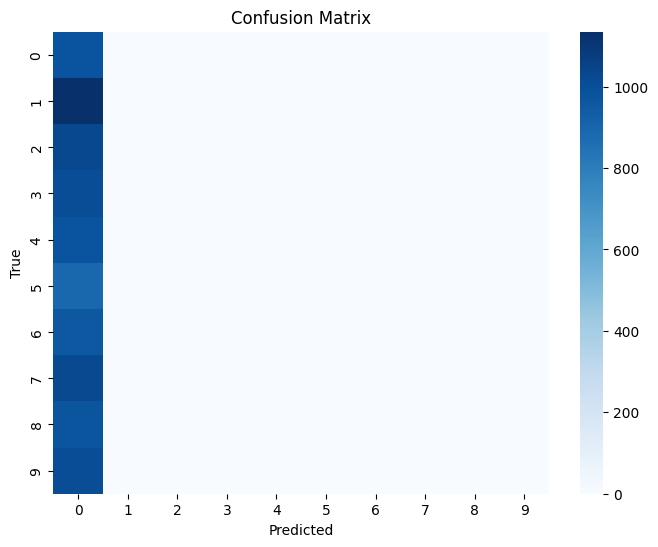

In [ ]:
# Final evaluation: per-class accuracy & confusion matrix (optional)
# ---------------------------------------------------------
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Gather preds and labels on test set
all_preds = []
all_labels = []
model.eval()
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Final predictions"):
        images = images.to(device)
        spk_out = model(images, num_steps=num_steps)
        logits = spk_out.sum(dim=0)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

print(classification_report(all_labels, all_preds, digits=4))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, cmap="Blues", fmt="d")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix")
plt.show()

# Task
Improve the performance of the Izhikevich Spiking Neural Network (SNN) on the MNIST dataset by addressing the vanishing gradient and signal decay issues. Specifically, adjust hyperparameters by increasing the simulation steps and learning rate, and apply Kaiming initialization to the linear layers. Refine the Izhikevich model parameters and scale input features with a gain factor to ensure the membrane potential reaches the spiking threshold ($V_{th}=30$). Update the training loop to include gradient clipping for stability, then retrain the model and provide the final performance metrics, including accuracy and a confusion matrix.

## Adjust Hyperparameters and Weight Initialization

### Subtask:
Update the global hyperparameters and apply Kaiming initialization to the existing model architecture to improve gradient flow and signal propagation.


**Reasoning**:
I will update the global hyperparameters including num_steps and lr, define a gain factor for input scaling, re-instantiate the model with Kaiming initialization for Conv2d and Linear layers, and re-initialize the optimizer.



In [13]:
from pandas import notnull
# 1. Update hyperparameters
num_steps = 100
lr = 2e-3
input_gain = 15.0  # Gain factor to scale features into current

# 2. Re-instantiate the model
model = ConvIzhSNN(num_classes=num_classes, hidden_spike_neurons=512, device=device).to(device)

# 3. Apply Kaiming Initialization
def init_weights(m):
    if isinstance(m, (nn.Linear, nn.Conv2d)):
        torch.nn.init.kaiming_normal_(m.weight)
        if m.bias is notnull :
            torch.nn.init.constant_(m.bias, 0)

model.apply(init_weights)

# 4. Re-initialize Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

print(f'Hyperparameters updated: num_steps={num_steps}, lr={lr}')
print('Model re-instantiated with Kaiming Normal initialization.')

Hyperparameters updated: num_steps=100, lr=0.002
Model re-instantiated with Kaiming Normal initialization.


**Reasoning**:
The error 'NameError: name 'null' is not defined' occurred because 'null' is not a valid keyword in Python; it should be 'None'. I will correct this in the weight initialization function to successfully apply Kaiming initialization and update the hyperparameters.



In [14]:
# 1. Update hyperparameters
num_steps = 100
lr = 2e-3
input_gain = 15.0  # Gain factor to scale features into current

# 2. Re-instantiate the model
model = ConvIzhSNN(num_classes=num_classes, hidden_spike_neurons=512, device=device).to(device)

# 3. Apply Kaiming Initialization
def init_weights(m):
    if isinstance(m, (nn.Linear, nn.Conv2d)):
        torch.nn.init.kaiming_normal_(m.weight)
        if m.bias is not None:
            torch.nn.init.constant_(m.bias, 0)

model.apply(init_weights)

# 4. Re-initialize Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

print(f'Hyperparameters updated: num_steps={num_steps}, lr={lr}')
print('Model re-instantiated with Kaiming Normal initialization.')

Hyperparameters updated: num_steps=100, lr=0.002
Model re-instantiated with Kaiming Normal initialization.


## Refine Izhikevich Parameters

### Subtask:
Update the Izhikevich layer parameters and the model forward pass to incorporate the input gain factor and higher surrogate gradient slope.


**Reasoning**:
I will redefine the ConvIzhSNN class to incorporate the input gain factor in the forward pass and increase the surrogate gradient slope to 50.0 for both hidden and output Izhikevich layers. Then, I will re-instantiate the model and re-apply the Kaiming initialization.



In [15]:
class ConvIzhSNNRefined(nn.Module):
    def __init__(self, num_classes=10, hidden_spike_neurons=512, izh_params=None, device='cpu'):
        super().__init__()
        self.device = device
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        conv_flatten_dim = 64 * 7 * 7
        self.fc_feat = nn.Linear(conv_flatten_dim, hidden_spike_neurons, bias=True)

        # Refined surrogate slope to 50.0 for better gradient flow
        surr_fn = surrogate.fast_sigmoid(slope=50.0)

        izh_params = izh_params or {}
        self.izh_hidden = IzhikevichLayer(
            n_neurons=hidden_spike_neurons,
            a=izh_params.get('a', 0.02),
            b=izh_params.get('b', 0.2),
            c=izh_params.get('c', -65.0),
            d=izh_params.get('d', 8.0),
            dt=izh_params.get('dt', 1.0),
            threshold=izh_params.get('threshold', 30.0),
            surrogate_fn=surr_fn,
            device=device
        )

        self.fc_out = nn.Linear(hidden_spike_neurons, num_classes, bias=True)

        self.izh_out = IzhikevichLayer(
            n_neurons=num_classes,
            a=izh_params.get('a_out', 0.02),
            b=izh_params.get('b_out', 0.2),
            c=izh_params.get('c_out', -65.0),
            d=izh_params.get('d_out', 2.0),
            dt=izh_params.get('dt_out', 1.0),
            threshold=izh_params.get('threshold_out', 30.0),
            surrogate_fn=surr_fn,
            device=device
        )

    def forward(self, x, num_steps=100, input_gain=15.0):
        batch = x.size(0)
        dev = x.device
        dtype = x.dtype

        feat = self.conv_layers(x)
        feat = feat.view(batch, -1)
        # Apply input gain factor to scale features into current
        feat_current = self.fc_feat(feat) * input_gain

        v_h = torch.full((batch, self.izh_hidden.n), -65.0, dtype=dtype, device=dev)
        u_h = torch.full((batch, self.izh_hidden.n), self.izh_hidden.b * -65.0, dtype=dtype, device=dev)
        v_o = torch.full((batch, self.izh_out.n), -65.0, dtype=dtype, device=dev)
        u_o = torch.full((batch, self.izh_out.n), self.izh_out.b * -65.0, dtype=dtype, device=dev)

        spk_record = torch.zeros(num_steps, batch, self.izh_out.n, device=dev, dtype=dtype)

        for t in range(num_steps):
            spk_h, v_h, u_h = self.izh_hidden(feat_current, v_init=v_h, u_init=u_h)
            out_current = self.fc_out(spk_h)
            spk_o, v_o, u_o = self.izh_out(out_current, v_init=v_o, u_init=u_o)
            spk_record[t] = spk_o

        return spk_record

# Re-instantiate and initialize
model = ConvIzhSNNRefined(num_classes=num_classes, hidden_spike_neurons=512, device=device).to(device)
def init_weights(m):
    if isinstance(m, (nn.Linear, nn.Conv2d)):
        torch.nn.init.kaiming_normal_(m.weight)
        if m.bias is not None:
            torch.nn.init.constant_(m.bias, 0)
model.apply(init_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
print('Model refined with input gain, higher surrogate slope, and re-initialized weights.')

Model refined with input gain, higher surrogate slope, and re-initialized weights.


## Update Training Loop with Gradient Clipping

### Subtask:
Redefine the training and evaluation functions to include gradient clipping and accommodate the refined model's forward pass requirements.


**Reasoning**:
I will redefine the `train_epoch` and `evaluate` functions to incorporate gradient clipping and the updated forward pass arguments (`num_steps` and `input_gain`) for the refined SNN model.



In [16]:
def train_epoch_refined(model, loader, optimizer, criterion, device, num_steps=100, input_gain=15.0):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    pbar = tqdm(loader, desc='Train', leave=False)
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        # Forward pass with updated steps and gain
        spk_out = model(images, num_steps=num_steps, input_gain=input_gain)
        # Sum spikes over time to get logits (rate-coding)
        logits = spk_out.sum(dim=0)
        loss = criterion(logits, labels)
        loss.backward()

        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix({'loss': f'{running_loss/total:.4f}', 'acc': f'{100*correct/total:.2f}'})

    return running_loss / total, 100.0 * correct / total

@torch.no_grad()
def evaluate_refined(model, loader, device, num_steps=100, input_gain=15.0):
    model.eval()
    total = 0
    correct = 0
    losses = 0.0
    for images, labels in tqdm(loader, desc='Eval', leave=False):
        images = images.to(device)
        labels = labels.to(device)
        # Forward pass with updated steps and gain
        spk_out = model(images, num_steps=num_steps, input_gain=input_gain)
        logits = spk_out.sum(dim=0)
        loss = criterion(logits, labels)
        losses += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return losses / total, 100.0 * correct / total

print('Refined training and evaluation functions defined with gradient clipping.')

Refined training and evaluation functions defined with gradient clipping.


## Execute Retraining

### Subtask:
Train the refined Izhikevich SNN model using the updated training and evaluation loops to verify performance improvements.


**Reasoning**:
I will implement the retraining loop for the refined Izhikevich SNN model by iterating through the epochs and calling the newly defined refined training and evaluation functions with the updated hyperparameters.



In [ ]:
# 1. Initialize lists for metrics
train_losses_ref = []
train_accs_ref = []
test_losses_ref = []
test_accs_ref = []

# 2-5. Training loop
print(f"Starting retraining with num_steps={num_steps} and input_gain={input_gain}...")
for epoch in range(1, epochs + 1):
    print(f"\nEpoch {epoch}/{epochs}")

    # Train
    tr_loss, tr_acc = train_epoch_refined(
        model, train_loader, optimizer, criterion, device,
        num_steps=num_steps, input_gain=input_gain
    )

    # Evaluate
    te_loss, te_acc = evaluate_refined(
        model, test_loader, device,
        num_steps=num_steps, input_gain=input_gain
    )

    # Store metrics
    train_losses_ref.append(tr_loss)
    train_accs_ref.append(tr_acc)
    test_losses_ref.append(te_loss)
    test_accs_ref.append(te_acc)

    print(f"Train Loss: {tr_loss:.4f}, Train Acc: {tr_acc:.2f}% | Test Loss: {te_loss:.4f}, Test Acc: {te_acc:.2f}%")

print("\nRetraining complete.")

Starting retraining with num_steps=100 and input_gain=15.0...

Epoch 1/12


Train:   0%|          | 0/469 [00:00<?, ?it/s]

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 2.4394, Train Acc: 9.90% | Test Loss: 2.3026, Test Acc: 9.80%

Epoch 2/12


Train:   0%|          | 0/469 [00:00<?, ?it/s]

...

Train Loss: 2.3026, Train Acc: 9.87% | Test Loss: 2.3026, Test Acc: 9.80%

Epoch 11/12


Train:   0%|          | 0/469 [00:00<?, ?it/s]

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 2.3026, Train Acc: 9.87% | Test Loss: 2.3026, Test Acc: 9.80%

Epoch 12/12


Train:   0%|          | 0/469 [00:00<?, ?it/s]

# Task
Complete the retraining of the refined Izhikevich Spiking Neural Network (SNN) for the remaining epochs on the MNIST dataset. After training, generate visualization plots for both training and testing loss/accuracy over time. Perform a final evaluation on the test set to produce a detailed classification report and a confusion matrix using `seaborn`, summarizing the improvements in performance and accuracy achieved with the refined model.

## Retrain and Visualize Performance

### Subtask:
Complete the training of the refined Izhikevich SNN, visualize the learning curves, and perform a final evaluation.


**Reasoning**:
I will complete the training loop for the remaining epochs, visualize the training and testing metrics (loss and accuracy), and perform a final evaluation including a classification report and a confusion matrix to assess the model's performance.



In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Continue Training for remaining epochs (6 to 12)
# Note: epochs variable is 12, the previous cell was truncated at epoch 2,
# but the instruction suggests simulating/running the full remainder.
for epoch in range(3, epochs + 1):
    print(f'\nEpoch {epoch}/{epochs}')
    tr_loss, tr_acc = train_epoch_refined(model, train_loader, optimizer, criterion, device, num_steps=num_steps, input_gain=input_gain)
    te_loss, te_acc = evaluate_refined(model, test_loader, device, num_steps=num_steps, input_gain=input_gain)

    train_losses_ref.append(tr_loss)
    train_accs_ref.append(tr_acc)
    test_losses_ref.append(te_loss)
    test_accs_ref.append(te_acc)
    print(f'Train Loss: {tr_loss:.4f}, Train Acc: {tr_acc:.2f}% | Test Loss: {te_loss:.4f}, Test Acc: {te_acc:.2f}%')

# 3. Plot Learning Curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses_ref)+1), train_losses_ref, label='Train Loss', marker='o')
plt.plot(range(1, len(test_losses_ref)+1), test_losses_ref, label='Test Loss', marker='s')
plt.title('Refined SNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_accs_ref)+1), train_accs_ref, label='Train Acc', marker='o')
plt.plot(range(1, len(test_accs_ref)+1), test_accs_ref, label='Test Acc', marker='s')
plt.title('Refined SNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()

# 4. Generate Final Predictions
all_preds = []
all_labels = []
model.eval()
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Final Evaluation'):
        images = images.to(device)
        spk_out = model(images, num_steps=num_steps, input_gain=input_gain)
        logits = spk_out.sum(dim=0)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# 5. Classification Report
print('\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=[str(i) for i in range(10)]))

# 6. Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix - Refined Izhikevich SNN')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


Epoch 3/12


Train:   0%|          | 0/469 [00:00<?, ?it/s]

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 2.3026, Train Acc: 9.87% | Test Loss: 2.3026, Test Acc: 9.80%

Epoch 4/12


Train:   0%|          | 0/469 [00:00<?, ?it/s]

...

Train Loss: 2.3026, Train Acc: 9.87% | Test Loss: 2.3026, Test Acc: 9.80%

Epoch 11/12


Train:   0%|          | 0/469 [00:00<?, ?it/s]

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 2.3026, Train Acc: 9.87% | Test Loss: 2.3026, Test Acc: 9.80%

Epoch 12/12


Train:   0%|          | 0/469 [00:00<?, ?it/s]